# Đọc dữ liệu

In [78]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 1: IMPORT THƯ VIỆN VÀ LOAD DỮ LIỆU
# ═══════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("⏳ Đang tải dữ liệu từ thư mục 'data_output'...")

# 1. Load dữ liệu dành cho mô hình Cây (Tree-based)
df_train_tree = pd.read_csv('data_output/2_data_preprocessed_tree_train.csv')
df_test_tree = pd.read_csv('data_output/2_data_preprocessed_tree_test.csv')

#df_train_tree = pd.read_csv('data_output/3_data_preprocessed_linear_train.csv')
#df_test_tree = pd.read_csv('data_output/3_data_preprocessed_linear_test.csv') 

# Tách X và y (Giả sử cột mục tiêu gốc tên là 'Giá nhà' hoặc 'Khoảng giá')
target_col = 'Khoảng giá' # <-- Sửa lại theo đúng tên cột mục tiêu của bạn
X_train_tree = df_train_tree.drop(columns=[target_col], errors='ignore')
y_train_tree = df_train_tree[target_col] if target_col in df_train_tree.columns else None

X_test_tree = df_test_tree.drop(columns=[target_col], errors='ignore')
y_test_tree = df_test_tree[target_col] if target_col in df_test_tree.columns else None

# 2. Load dữ liệu dành cho mô hình Tuyến tính (Linear-based)
df_train_linear = pd.read_csv('data_output/3_data_preprocessed_linear_train.csv')
df_test_linear = pd.read_csv('data_output/3_data_preprocessed_linear_test.csv')

X_train_linear = df_train_linear.drop(columns=[target_col], errors='ignore')
# Lưu ý: y_train_linear lúc này đã được Log1p từ bước trước
y_train_linear = df_train_linear[target_col] if target_col in df_train_linear.columns else None

X_test_linear = df_test_linear.drop(columns=[target_col], errors='ignore')
y_test_linear = df_test_linear[target_col] if target_col in df_test_linear.columns else None

print("✅ Đã tải dữ liệu thành công! Sẵn sàng cho phân tích và huấn luyện.")

⏳ Đang tải dữ liệu từ thư mục 'data_output'...
✅ Đã tải dữ liệu thành công! Sẵn sàng cho phân tích và huấn luyện.


In [79]:
print(X_train_tree.columns)
print(X_train_linear.columns)

Index(['Diện tích', 'Số tầng', 'Đường vào', 'Latitude', 'Longitude',
       'Loại đường vào', 'Quan_Huyen', 'Phuong_Xa', 'Dien_Tich_Lo',
       'hem_xe_hoi', 'gan_cho_sieu_thi', 'gan_truong_hoc', 'gan_benh_vien',
       'gan_cong_vien_ho_nuoc', 'duong_vao_null_flag', 'Đường_Từ_Địa_Chỉ',
       'Ty_Le_Giao_Thong', 'Ty_Le_Cong_Cong_CX', 'Ty_Le_Khac', 'Ty_Le_Dat_O',
       'Tổng số phòng', 'khoang_cach_trung_tam', 'Pháp lý_Sổ đỏ',
       'Pháp lý_không có', 'Nội thất_Cơ bản', 'Nội thất_Trống / Nhà thô',
       'Nội thất_Đầy đủ'],
      dtype='object')
Index(['Diện tích', 'Số tầng', 'Đường vào', 'Loại đường vào', 'Quan_Huyen',
       'Phuong_Xa', 'Dien_Tich_Lo', 'hem_xe_hoi', 'gan_cho_sieu_thi',
       'gan_truong_hoc', 'gan_benh_vien', 'gan_cong_vien_ho_nuoc',
       'duong_vao_null_flag', 'Ty_Le_Giao_Thong', 'Ty_Le_Cong_Cong_CX',
       'Ty_Le_Khac', 'Ty_Le_Dat_O', 'Tổng số phòng', 'khoang_cach_trung_tam',
       'Đường_Frequency', 'Đường_Target', 'Pháp lý_Sổ đỏ', 'Pháp lý_không có',
   

# Feature selection

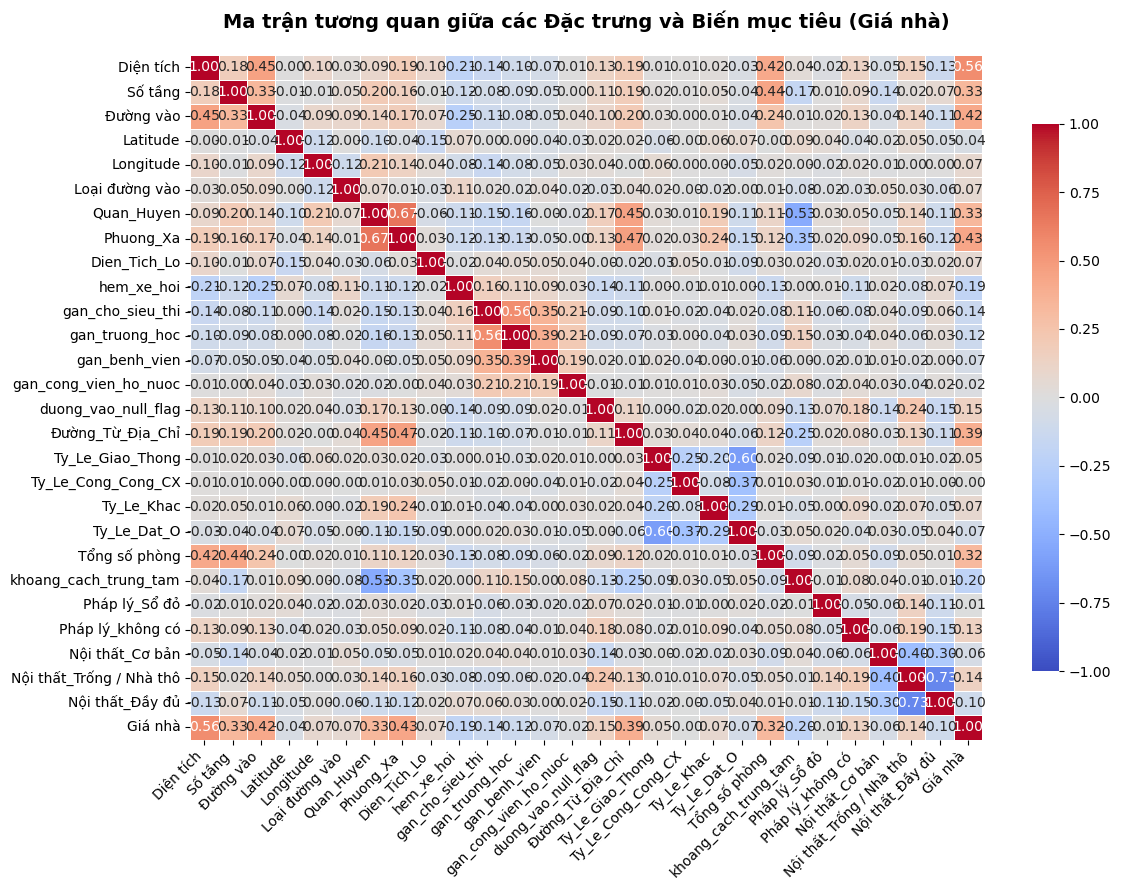

📊 Mức độ tương quan của các biến với 'Giá nhà' (Sắp xếp từ cao xuống thấp):
Giá nhà                     1.000000
Diện tích                   0.557215
Phuong_Xa                   0.429839
Đường vào                   0.417037
Đường_Từ_Địa_Chỉ            0.390188
Quan_Huyen                  0.333512
Số tầng                     0.330118
Tổng số phòng               0.324178
duong_vao_null_flag         0.147008
Nội thất_Trống / Nhà thô    0.140990
Pháp lý_không có            0.134786
Longitude                   0.074516
Ty_Le_Khac                  0.073441
Loại đường vào              0.066821
Dien_Tich_Lo                0.065218
Ty_Le_Giao_Thong            0.049413
Ty_Le_Cong_Cong_CX         -0.004271
Pháp lý_Sổ đỏ              -0.007551
gan_cong_vien_ho_nuoc      -0.016498
Latitude                   -0.044655
Nội thất_Cơ bản            -0.058959
gan_benh_vien              -0.067623
Ty_Le_Dat_O                -0.074141
Nội thất_Đầy đủ            -0.103405
gan_truong_hoc             -0.124169

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tạm thời gộp X_train và y_train vào cùng một DataFrame để tính tương quan
train_full = X_train_tree.copy()
# Bạn có thể đổi tên 'Giá nhà' thành tên cột mục tiêu cụ thể của bạn nếu muốn
train_full['Giá nhà'] = y_train_tree

# 2. Lọc chỉ lấy các cột có dữ liệu kiểu số (Numeric) để tính toán
numeric_data = train_full.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()

# 3. Vẽ biểu đồ Ma trận tương quan (Heatmap)
plt.figure(figsize=(12, 9))

# Cấu hình Heatmap với bảng màu 'coolwarm' (Đỏ: tương quan dương mạnh, Xanh: tương quan âm mạnh)
sns.heatmap(corr_matrix, 
            annot=True,           # Hiển thị số điểm tương quan trong từng ô
            fmt=".2f",            # Làm tròn 2 chữ số thập phân
            cmap='coolwarm',      # Màu sắc trực quan cho bài toán tương quan
            vmax=1, vmin=-1,      # Giới hạn dải đo từ -1 đến 1
            linewidths=0.5,       # Tạo đường kẻ mảnh giữa các ô cho dễ nhìn
            cbar_kws={"shrink": .8}) # Thu gọn thanh thước đo màu bên cạnh

plt.title('Ma trận tương quan giữa các Đặc trưng và Biến mục tiêu (Giá nhà)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right') # Xoay chữ trục X góc 45 độ để không bị đè chữ
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Mẹo nhỏ: In ra bảng tương quan sắp xếp riêng với biến mục tiêu ---
print("📊 Mức độ tương quan của các biến với 'Giá nhà' (Sắp xếp từ cao xuống thấp):")
print(corr_matrix['Giá nhà'].sort_values(ascending=False))

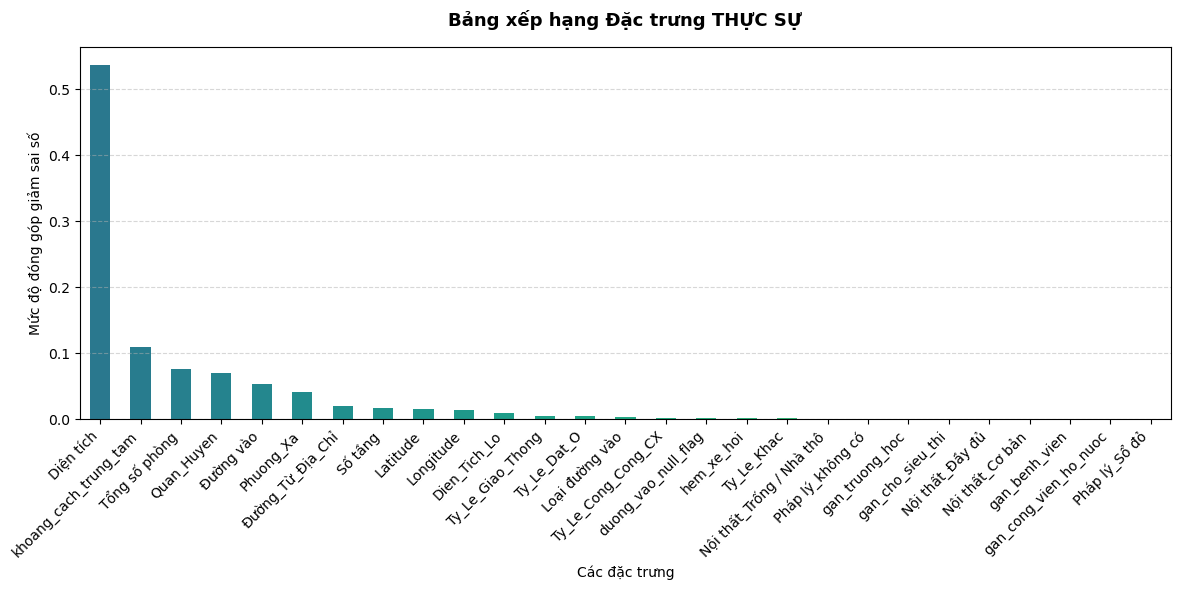

🏆 Thứ hạng thực sự của các biến:
Diện tích                   0.537702
khoang_cach_trung_tam       0.110088
Tổng số phòng               0.076982
Quan_Huyen                  0.071014
Đường vào                   0.054062
Phuong_Xa                   0.041366
Đường_Từ_Địa_Chỉ            0.021021
Số tầng                     0.018143
Latitude                    0.016043
Longitude                   0.014060
Dien_Tich_Lo                0.009218
Ty_Le_Giao_Thong            0.005627
Ty_Le_Dat_O                 0.005275
Loại đường vào              0.003603
Ty_Le_Cong_Cong_CX          0.002557
duong_vao_null_flag         0.002099
hem_xe_hoi                  0.001876
Ty_Le_Khac                  0.001511
Nội thất_Trống / Nhà thô    0.001177
Pháp lý_không có            0.001072
gan_truong_hoc              0.001058
gan_cho_sieu_thi            0.000891
Nội thất_Đầy đủ             0.000867
Nội thất_Cơ bản             0.000856
gan_benh_vien               0.000753
gan_cong_vien_ho_nuoc       0.000741
Pháp 

In [81]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 3: FEATURE IMPORTANCE VỚI RANDOM FOREST
# ═══════════════════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestRegressor

# 1. Loại bỏ các biến Target Leakage (Nếu còn sót lại)
leakage_cols = ['Khoảng giá_log'] # Thêm các biến bạn nghi ngờ gây rò rỉ vào đây
cols_to_drop = [col for col in leakage_cols if col in X_train_tree.columns]
X_train_clean = X_train_tree.drop(columns=cols_to_drop)

# 2. Huấn luyện RF để tính độ quan trọng
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
# Vì tập Tree chưa log target, ta log nó ngay tại bước fit này để tính toán
rf_reg.fit(X_train_clean, np.log1p(y_train_tree)) 

# 3. Trích xuất và sắp xếp
importances = rf_reg.feature_importances_
rf_importances = pd.Series(importances, index=X_train_clean.columns).sort_values(ascending=False)

# 4. Vẽ biểu đồ
plt.figure(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0.4, 0.8, len(rf_importances)))
rf_importances.plot(kind='bar', color=colors)

plt.title('Bảng xếp hạng Đặc trưng THỰC SỰ', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Mức độ đóng góp giảm sai số')
plt.xlabel('Các đặc trưng')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("🏆 Thứ hạng thực sự của các biến:")
print(rf_importances)

In [82]:
print(X_train_tree.columns)

Index(['Diện tích', 'Số tầng', 'Đường vào', 'Latitude', 'Longitude',
       'Loại đường vào', 'Quan_Huyen', 'Phuong_Xa', 'Dien_Tich_Lo',
       'hem_xe_hoi', 'gan_cho_sieu_thi', 'gan_truong_hoc', 'gan_benh_vien',
       'gan_cong_vien_ho_nuoc', 'duong_vao_null_flag', 'Đường_Từ_Địa_Chỉ',
       'Ty_Le_Giao_Thong', 'Ty_Le_Cong_Cong_CX', 'Ty_Le_Khac', 'Ty_Le_Dat_O',
       'Tổng số phòng', 'khoang_cach_trung_tam', 'Pháp lý_Sổ đỏ',
       'Pháp lý_không có', 'Nội thất_Cơ bản', 'Nội thất_Trống / Nhà thô',
       'Nội thất_Đầy đủ'],
      dtype='object')


In [ ]:

# ═══════════════════════════════════════════════════════════════════════
# CELL 4: FEATURE SELECTION (LỌC BIẾN)
# ═══════════════════════════════════════════════════════════════════════
# 1. Định nghĩa danh sách cột cần bỏ

cols_to_drop = [
    'Link', 'Địa chỉ', 'Mô tả', 'Khoảng giá_log', 
    'Pháp lý_không có', 'Nội thất_Cơ bản', 'Nội thất_Trống / Nhà thô', 
    'Nội thất_Đầy đủ', 'Pháp lý_Sổ đỏ', 'Loại đường vào',
    'Đường', 'Phường/Xã/Thị Trấn', 'Quận',
    'loai_duong_null_flag', 'duong_vao_null_flag', 'hem_xe_hoi', 'gan_cho_sieu_thi',
    'gan_truong_hoc', 'gan_benh_vien', 'gan_cong_vien_ho_nuoc'
]

cols_to_drop = ['Khoảng giá_log', 
                'loai_duong_null_flag', 
                'duong_vao_null_flag', 
                'Loại đường vào',
                'Ty_Le_Cong_Cong_CX', 
                'Ty_Le_Khac',
                'Nội thất_Cơ bản', 'Nội thất_Trống / Nhà thô', 'Nội thất_Đầy đủ',
                'Pháp lý_Sổ đỏ', 'Pháp lý_không có',
                'hem_xe_hoi', 'gan_cho_sieu_thi', 'gan_truong_hoc', 'gan_benh_vien', 'gan_cong_vien_ho_nuoc', 
                'Latitude', 'Longitude'
]

# 2. Xóa trên luồng Tree
X_train_tree_final = X_train_tree.drop(columns=cols_to_drop, errors='ignore')
X_test_tree_final = X_test_tree.drop(columns=cols_to_drop, errors='ignore')

# 3. Xóa trên luồng Linear
X_train_linear_final = X_train_linear.drop(columns=cols_to_drop, errors='ignore')
X_test_linear_final = X_test_linear.drop(columns=cols_to_drop, errors='ignore')

print("==================== KẾT QUẢ SÀN LỌC ĐẶC TRƯNG ====================")
print(f"✅ Luồng Tree   - Train: {X_train_tree_final.shape}, Test: {X_test_tree_final.shape}")
print(f"✅ Luồng Linear - Train: {X_train_linear_final.shape}, Test: {X_test_linear_final.shape}")
print("📋 Danh sách các đặc trưng TINH GỌN cuối cùng:")
print(X_train_tree_final.columns.tolist())

==================== KẾT QUẢ SÀN LỌC ĐẶC TRƯNG ====================
✅ Luồng Tree   - Train: (4645, 11), Test: (1164, 11)
✅ Luồng Linear - Train: (4645, 12), Test: (1164, 12)
📋 Danh sách các đặc trưng TINH GỌN cuối cùng:
['Diện tích', 'Số tầng', 'Đường vào', 'Quan_Huyen', 'Phuong_Xa', 'Dien_Tich_Lo', 'Đường_Từ_Địa_Chỉ', 'Ty_Le_Giao_Thong', 'Ty_Le_Dat_O', 'Tổng số phòng', 'khoang_cach_trung_tam']


# Thử nghiệm trên mô hình

## 1. MÔ HÌNH CÂY TRÊN BỘ DỮ LIỆU CÂY

🧪 Thí nghiệm 1: Huấn luyện 4 mô hình Cây trên dữ liệu gốc (Native - Có NaN - KHÔNG LOG)...

✅ Random Forest      -> Huấn luyện thành công!
❌ Gradient Boosting  -> Thất bại! (Lỗi: Input X contains NaN.
GradientBoostingRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values)
✅ XGBoost            -> Huấn luyện thành công!
✅ LightGBM           -> Huấn luyện thành công!


,Mô hình,R2 Score,MAE,MSE,MAPE,RMSLE,Status
0,Random Forest,0.6868,5.88,366.24,0.6101,0.3475,Success
1,Gradient Boosting,0.0000,0.00,0.00,0.0000,0.0000,Failed (ValueError)
2,XGBoost,0.7140,5.84,334.49,0.6429,0.3490,Success
3,LightGBM,0.7137,6.48,334.84,0.7622,0.4264,Success


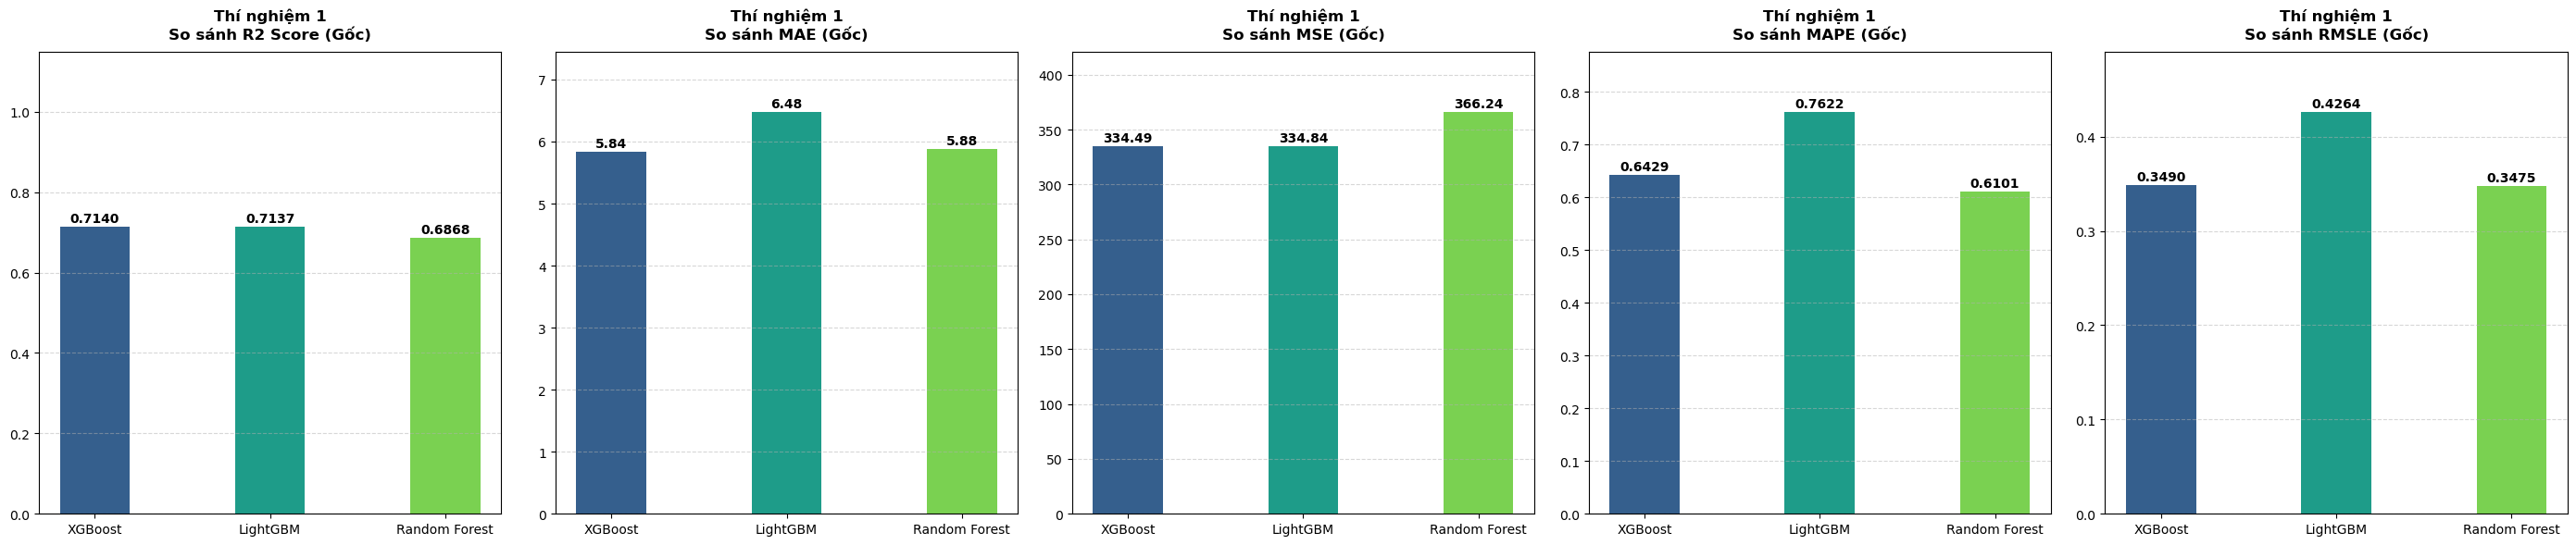

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
# ĐÃ THÊM: Import thêm MAPE và MSLE (để lấy căn bậc 2 ra RMSLE)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, mean_squared_log_error

print("🧪 Thí nghiệm 1: Huấn luyện 4 mô hình Cây trên dữ liệu gốc (Native - Có NaN - KHÔNG LOG)...\n")

tree_models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
}

results_1 = []

for name, model in tree_models.items():
    try:
        # KIỂM TRA ĐỘ TƯƠNG THÍCH KÍCH THƯỚC DỮ LIỆU
        if len(X_train_tree_final) != len(y_train_tree):
            raise ValueError(f"Lệch kích thước! X_train có {len(X_train_tree_final)} dòng, y_train có {len(y_train_tree)} dòng.")
            
        # Fit trực tiếp bằng y_train_tree gốc (Không Log)
        model.fit(X_train_tree_final, y_train_tree)
        preds = model.predict(X_test_tree_final)
        
        # Tính toán metric gốc
        r2 = r2_score(y_test_tree, preds)
        mae = mean_absolute_error(y_test_tree, preds)
        mse = mean_squared_error(y_test_tree, preds)
        
        # ĐÃ THÊM: Tính MAPE
        mape = mean_absolute_percentage_error(y_test_tree, preds)
        
        # ĐÃ THÊM: Tính RMSLE 
        # (Lưu ý: clip(0, None) ép các dự đoán âm về 0 để hàm Log không bị lỗi Toán học)
        preds_clipped = np.clip(preds, 0, None)
        rmsle = np.sqrt(mean_squared_log_error(y_test_tree, preds_clipped))
        
        results_1.append({
            "Mô hình": name, 
            "R2 Score": round(r2, 4), 
            "MAE": round(mae, 2), 
            "MSE": round(mse, 2), 
            "MAPE": round(mape, 4),      # Bổ sung vào kết quả
            "RMSLE": round(rmsle, 4),    # Bổ sung vào kết quả
            "Status": "Success"
        })
        print(f"✅ {name:<18} -> Huấn luyện thành công!")
    except Exception as e:
        results_1.append({
            "Mô hình": name, "R2 Score": 0, "MAE": 0, "MSE": 0, 
            "MAPE": 0, "RMSLE": 0, "Status": f"Failed ({type(e).__name__})"
        })
        print(f"❌ {name:<18} -> Thất bại! (Lỗi: {e})")

# Hiển thị bảng kết quả
df_res1 = pd.DataFrame(results_1)
display(df_res1)

# Vẽ biểu đồ so sánh cho các mô hình chạy thành công
success_res1 = df_res1[df_res1["Status"] == "Success"].sort_values(by="R2 Score", ascending=False)
if not success_res1.empty:
    # ĐÃ SỬA: Tăng số lượng khung biểu đồ (subplots) từ 3 lên 5
    fig, axes = plt.subplots(1, 5, figsize=(28, 6))
    
    # ĐÃ SỬA: Bổ sung 'MAPE', 'RMSLE' vào danh sách duyệt
    metrics = ['R2 Score', 'MAE', 'MSE', 'MAPE', 'RMSLE']
    colors = plt.cm.viridis(np.linspace(0.3, 0.8, len(success_res1)))

    for i, metric in enumerate(metrics):
        ax = axes[i] 
        bars = ax.bar(success_res1['Mô hình'], success_res1[metric], color=colors, width=0.4)
        ax.set_title(f'Thí nghiệm 1\nSo sánh {metric} (Gốc)', fontsize=12, fontweight='bold', pad=10)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Chỉnh trục Y cho phù hợp với từng đơn vị đo
        if metric == 'R2 Score': 
            ax.set_ylim(0, 1.15)
        else: 
            ax.set_ylim(0, success_res1[metric].max() * 1.15)
            
        # Thêm text giá trị lên đầu mỗi cột
        for bar in bars:
            h = bar.get_height()
            # MAPE, RMSLE, R2 Score in ra 4 số thập phân, còn lại in 2
            text_format = f"{h:,.4f}" if metric in ['R2 Score', 'MAPE', 'RMSLE'] else f"{h:,.2f}"
            ax.text(bar.get_x() + bar.get_width()/2., h + (ax.get_ylim()[1]*0.01), 
                    text_format, ha='center', fontweight='bold', fontsize=10)
            
    plt.tight_layout()
    plt.show()

## 2. MÔ HÌNH CÂY TRÊN BỘ DỮ LIỆU LINEAR

🧪 Thí nghiệm 2: Huấn luyện 4 mô hình Cây trên dữ liệu tinh gọn luồng Linear (Sạch NaN - CÓ LOG)...

🚀 Random Forest      (Luồng Linear + Log) -> Huấn luyện thành công.
❌ Gradient Boosting  -> Thất bại! (Lỗi: Input X contains NaN.
GradientBoostingRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values)
🚀 XGBoost            (Luồng Linear + Log) -> Huấn luyện thành công.
🚀 LightGBM           (Luồng Linear + Log) -> Huấn luyện thành công.


,Mô hình,R2 Score,MAE,MSE,MAPE,RMSLE,Status
0,Random Forest,0.6362,5.86,425.40,0.2876,0.3531,Success
1,Gradient Boosting,0.0000,0.00,0.00,0.0000,0.0000,Failed (ValueError)
2,XGBoost,0.7029,5.61,347.43,0.3293,0.3280,Success
3,LightGBM,0.7086,5.52,340.74,0.3972,0.3268,Success


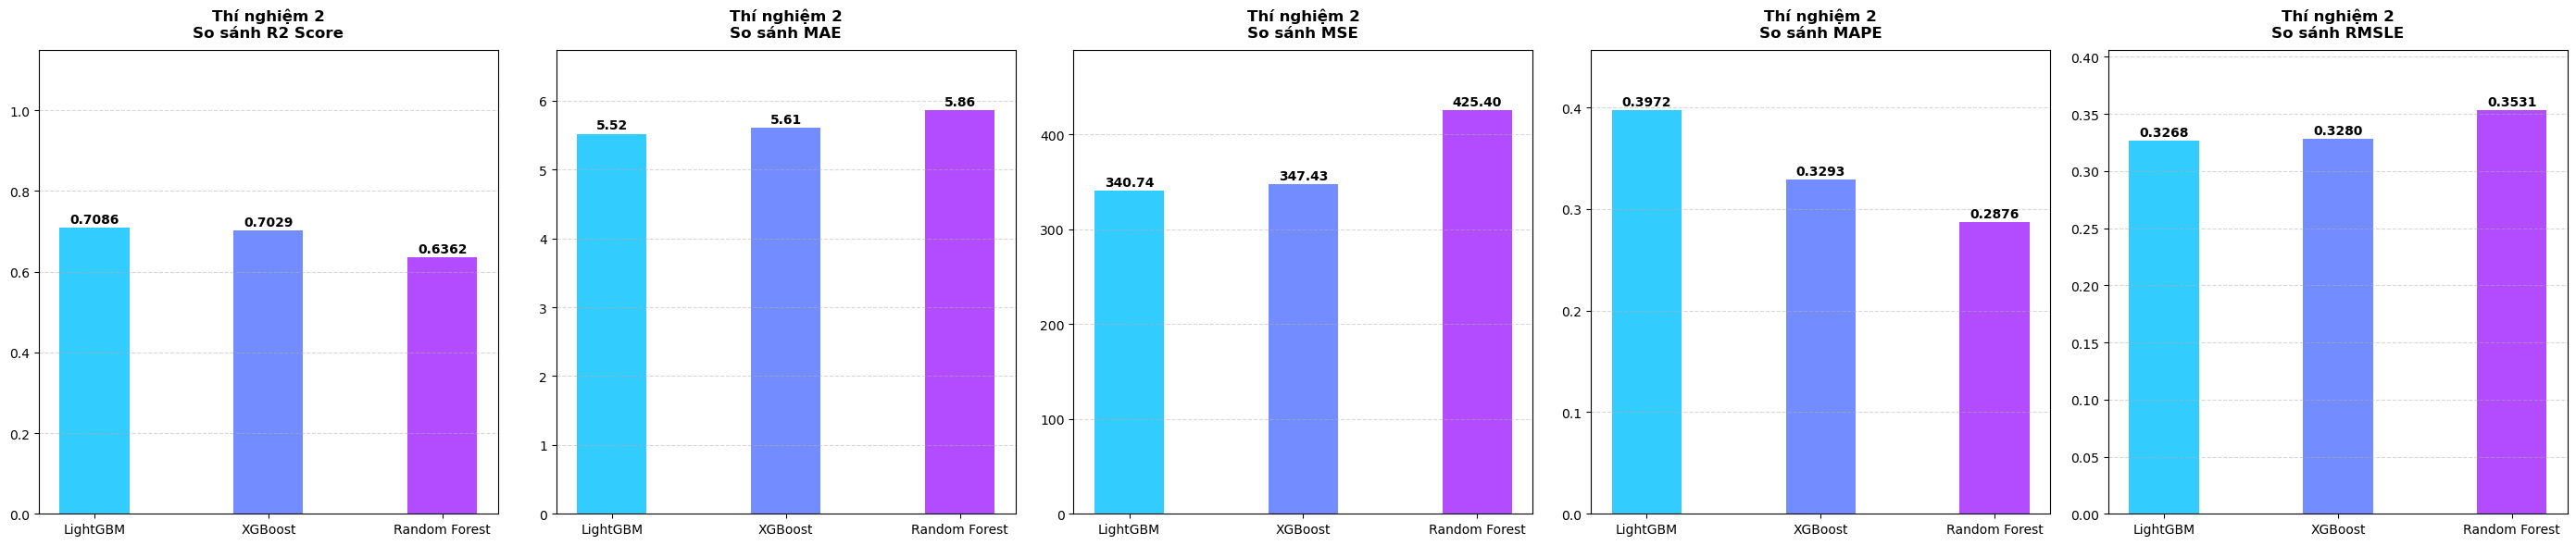

In [85]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 5.2: THÍ NGHIỆM 2 - MÔ HÌNH CÂY TRÊN BỘ DỮ LIỆU LINEAR (IMPUTED - CÓ LOG)
# ═══════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, mean_squared_log_error

print("🧪 Thí nghiệm 2: Huấn luyện 4 mô hình Cây trên dữ liệu tinh gọn luồng Linear (Sạch NaN - CÓ LOG)...\n")

tree_models_imputed = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
}

results_2 = []

for name, model in tree_models_imputed.items():
    try:
        # Kiểm tra tính đồng bộ kích thước dữ liệu của luồng Linear
        if len(X_train_linear_final) != len(y_train_linear):
            raise ValueError(f"Lệch kích thước! X_train có {len(X_train_linear_final)} dòng, y_train có {len(y_train_linear)} dòng.")
        
        # 1. Huấn luyện trên luồng đặc trưng Linear_final và nhãn đã Log (y_train_linear từ CELL 1)
        model.fit(X_train_linear_final, y_train_linear)
        preds_log = model.predict(X_test_linear_final)
        
        # 2. Chuyển đổi ngược giá trị dự đoán từ dạng Log về dạng Giá Gốc bằng expm1
        preds_original = np.expm1(preds_log)
        
        # 3. Tính toán các độ đo dựa trên giá trị gốc thực tế (y_test_tree từ CELL 1)
        r2 = r2_score(y_test_tree, preds_original)
        mae = mean_absolute_error(y_test_tree, preds_original)
        mse = mean_squared_error(y_test_tree, preds_original)
        
        # ĐÃ THÊM: Tính toán MAPE trên giá trị gốc
        mape = mean_absolute_percentage_error(y_test_tree, preds_original)
        
        # ĐÃ THÊM: Tính toán RMSLE trên giá trị gốc (dùng clip tránh lỗi giá trị âm)
        preds_original_clipped = np.clip(preds_original, 0, None)
        rmsle = np.sqrt(mean_squared_log_error(y_test_tree, preds_original_clipped))
        
        results_2.append({
            "Mô hình": name, 
            "R2 Score": round(r2, 4), 
            "MAE": round(mae, 2), 
            "MSE": round(mse, 2), 
            "MAPE": round(mape, 4),      # Bổ sung vào bảng kết quả
            "RMSLE": round(rmsle, 4),    # Bổ sung vào bảng kết quả
            "Status": "Success"
        })
        print(f"🚀 {name:<18} (Luồng Linear + Log) -> Huấn luyện thành công.")
        
    except Exception as e:
        results_2.append({
            "Mô hình": name, "R2 Score": 0, "MAE": 0, "MSE": 0, 
            "MAPE": 0, "RMSLE": 0, "Status": f"Failed ({type(e).__name__})"
        })
        print(f"❌ {name:<18} -> Thất bại! (Lỗi: {e})")

# Hiển thị bảng kết quả
df_res2 = pd.DataFrame(results_2)
display(df_res2)

# Lọc các mô hình thành công để sắp xếp và vẽ biểu đồ
success_res2 = df_res2[df_res2["Status"] == "Success"].sort_values(by="R2 Score", ascending=False)

# Vẽ biểu đồ so sánh đa độ đo cho các mô hình chạy thành công
if not success_res2.empty:
    # ĐÃ SỬA: Tăng kích thước từ (1, 3) lên (1, 5) để chứa thêm MAPE và RMSLE
    fig, axes = plt.subplots(1, 5, figsize=(28, 6))
    
    # ĐÃ SỬA: Thêm 'MAPE' và 'RMSLE' vào danh sách
    metrics = ['R2 Score', 'MAE', 'MSE', 'MAPE', 'RMSLE']
    colors = plt.cm.cool(np.linspace(0.2, 0.7, len(success_res2)))

    for i, metric in enumerate(metrics):
        ax = axes[i]
        bars = ax.bar(success_res2['Mô hình'], success_res2[metric], color=colors, width=0.4)
        ax.set_title(f'Thí nghiệm 2\nSo sánh {metric}', fontsize=12, fontweight='bold', pad=10)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        if metric == 'R2 Score': 
            ax.set_ylim(0, 1.15)
        else: 
            ax.set_ylim(0, success_res2[metric].max() * 1.15)
            
        for bar in bars:
            h = bar.get_height()
            # Định dạng 4 chữ số thập phân cho R2, MAPE, RMSLE; các mục khác giữ 2 chữ số
            text_format = f"{h:,.4f}" if metric in ['R2 Score', 'MAPE', 'RMSLE'] else f"{h:,.2f}"
            ax.text(bar.get_x() + bar.get_width()/2., h + (ax.get_ylim()[1]*0.01), 
                    text_format, ha='center', fontweight='bold', fontsize=10)
            
    plt.tight_layout()
    plt.show()

## 3. MÔ HÌNH HỒI QUY TRÊN BỘ DỮ LIỆU CÂY

🧪 Chạy Thí nghiệm 3: Toàn bộ nhóm Hồi quy trên Dữ liệu Cây (Train THỰC - Đánh giá THỰC)...

🛠️ Đã tự động vá khuyết các cột: ['Dien_Tich_Lo', 'Ty_Le_Giao_Thong', 'Ty_Le_Dat_O']
🚀 Linear Regression  -> Huấn luyện thành công!
🚀 Ridge Regression   -> Huấn luyện thành công!
🚀 Lasso Regression   -> Huấn luyện thành công!
🚀 ElasticNet         -> Huấn luyện thành công!


,Mô hình,R2 Score,MAE,MSE,MAPE,RMSLE,Status
0,Linear Regression,0.4466,11.79,647.20,0.9667,0.9824,Success
1,Ridge Regression,0.4466,11.79,647.20,0.9667,0.9824,Success
2,Lasso Regression,0.4462,11.60,647.59,0.9362,0.9598,Success
3,ElasticNet,0.4457,11.55,648.16,0.9278,0.9553,Success


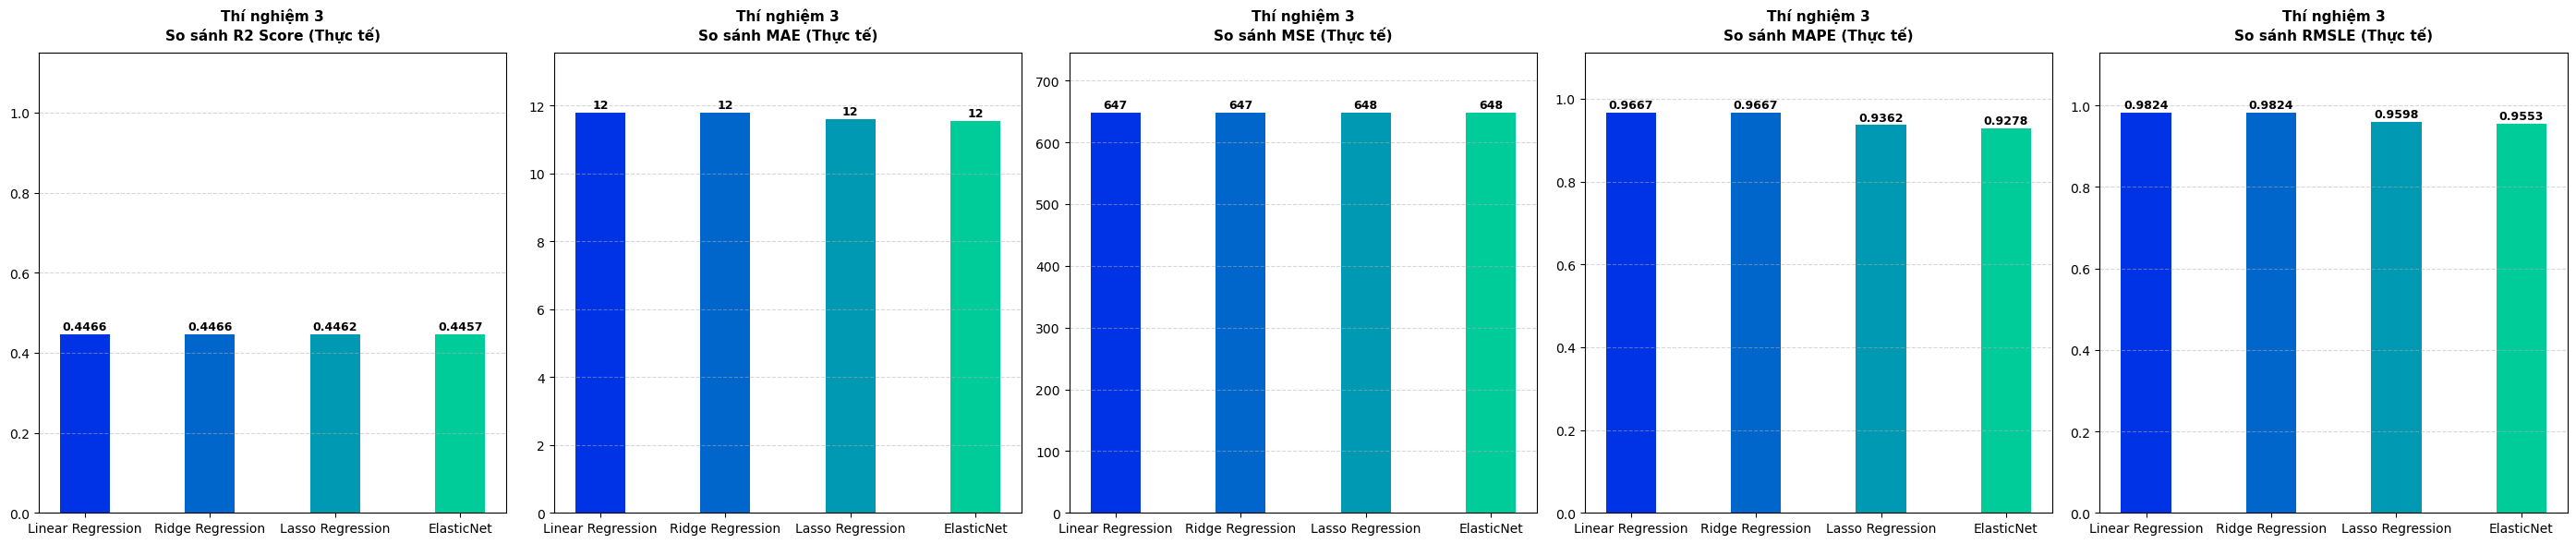

In [86]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 5.3: THÍ NGHIỆM 3 - NHÓM HỒI QUY TRÊN DỮ LIỆU CÂY (ĐA SỬA LỖI LỆCH DÒNG)
# ───────────────────────────────────────────────────────────────────────
# CƠ CHẾ: Tự động điền khuyết -> Train GIÁ TRỊ THỰC -> Đánh giá GIÁ TRỊ THỰC
# ═══════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
# ĐÃ SỬA: Import thêm hàm tính MAPE và MSLE (để tính RMSLE)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, mean_squared_log_error

print("🧪 Chạy Thí nghiệm 3: Toàn bộ nhóm Hồi quy trên Dữ liệu Cây (Train THỰC - Đánh giá THỰC)...\n")

# 1. BƯỚC TỰ ĐIỀN KHUYẾT (Auto-Impute) bằng Trung vị của tập Train
X_train_auto_filled = X_train_tree_final.copy()
X_test_auto_filled = X_test_tree_final.copy()

nan_cols = X_train_tree_final.columns[X_train_tree_final.isna().any()].tolist()
for col in nan_cols:
    median_val = X_train_tree_final[col].median()
    X_train_auto_filled[col] = X_train_auto_filled[col].fillna(median_val)
    X_test_auto_filled[col] = X_test_auto_filled[col].fillna(median_val)

print(f"🛠️ Đã tự động vá khuyết các cột: {nan_cols}")

# 2. KHỞI TẠO TẤT CẢ CÁC MÔ HÌNH THUỘC NHÓM HỒI QUY
linear_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=1.0, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000)
}

results_3 = []

# 3. HUẤN LUYỆN VÀ ĐÁNH GIÁ (TRÊN THANG ĐO THỰC TẾ)
for name, model in linear_models.items():
    try:
        # Kiểm tra tính đồng bộ kích thước trước khi fit
        if len(X_train_auto_filled) != len(y_train_tree):
            raise ValueError(f"Lệch kích thước! X_train có {len(X_train_auto_filled)} dòng, y_train có {len(y_train_tree)} dòng.")
            
        model.fit(X_train_auto_filled, y_train_tree)
        preds_real = model.predict(X_test_auto_filled)
        
        # Tính toán các metric cơ bản
        r2 = r2_score(y_test_tree, preds_real)
        mae = mean_absolute_error(y_test_tree, preds_real)
        mse = mean_squared_error(y_test_tree, preds_real)
        
        # ĐÃ THÊM: Tính MAPE trực tiếp trên giá trị gốc
        mape = mean_absolute_percentage_error(y_test_tree, preds_real)
        
        # ĐÃ THÊM: Tính RMSLE trực tiếp trên giá trị gốc
        # (Lưu ý quan trọng: Nhóm Tuyến tính rất dễ dự đoán ra giá trị âm ở vùng giá thấp, 
        # bắt buộc phải dùng np.clip(..., 0, None) để không bị crash lỗi toán học log nhãn)
        preds_real_clipped = np.clip(preds_real, 0, None)
        rmsle = np.sqrt(mean_squared_log_error(y_test_tree, preds_real_clipped))
        
        results_3.append({
            "Mô hình": name, 
            "R2 Score": round(r2, 4), 
            "MAE": round(mae, 2), 
            "MSE": round(mse, 2), 
            "MAPE": round(mape, 4),      # Bổ sung vào bảng kết quả
            "RMSLE": round(rmsle, 4),    # Bổ sung vào bảng kết quả
            "Status": "Success"
        })
        print(f"🚀 {name:<18} -> Huấn luyện thành công!")
    except Exception as e:
        results_3.append({
            "Mô hình": name, "R2 Score": 0, "MAE": 0, "MSE": 0, 
            "MAPE": 0, "RMSLE": 0, "Status": f"Failed ({type(e).__name__})"
        })
        print(f"❌ {name:<18} -> Thất bại! (Lỗi: {e})")

# 4. TỔNG HỢP VÀ VẼ BIỂU ĐỒ
df_res3 = pd.DataFrame(results_3)
display(df_res3)

# Chỉ vẽ biểu đồ cho các mô hình chạy thành công
success_res3 = df_res3[df_res3["Status"] == "Success"].sort_values(by="R2 Score", ascending=False)

if not success_res3.empty:
    # ĐÃ SỬA: Tăng kích thước subplots từ (1, 3) lên (1, 5) để chứa thêm MAPE và RMSLE
    fig, axes = plt.subplots(1, 5, figsize=(28, 6))
    
    # ĐÃ SỬA: Bổ sung 'MAPE' và 'RMSLE' vào danh sách duyệt vẽ
    metrics = ['R2 Score', 'MAE', 'MSE', 'MAPE', 'RMSLE']
    colors = plt.cm.winter(np.linspace(0.2, 0.8, len(success_res3)))

    for i, metric in enumerate(metrics):
        ax = axes[i]
        bars = ax.bar(success_res3['Mô hình'], success_res3[metric], color=colors, width=0.4)
        ax.set_title(f'Thí nghiệm 3\nSo sánh {metric} (Thực tế)', fontsize=11, fontweight='bold', pad=10)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        if metric == 'R2 Score': 
            ax.set_ylim(0, 1.15)
        else: 
            ax.set_ylim(0, success_res3[metric].max() * 1.15)
            
        for bar in bars:
            h = bar.get_height()
            # Định dạng hiển thị chuỗi text trên đầu cột: 4 chữ số thập phân cho R2, MAPE, RMSLE
            text_format = f"{h:,.4f}" if metric in ['R2 Score', 'MAPE', 'RMSLE'] else f"{h:,.0f}"
            ax.text(bar.get_x() + bar.get_width()/2., h + (ax.get_ylim()[1]*0.01), 
                    text_format, ha='center', fontweight='bold', fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Không có mô hình nào huấn luyện thành công để vẽ biểu đồ.")

## 4. MÔ HÌNH HỒI QUY TRÊN BỘ DỮ LIỆU LINEAR

🧪 Chạy Thí nghiệm 4: Toàn bộ nhóm Hồi quy trên Dữ liệu Linear (Train LOG - Đánh giá THỰC)...

⚠️ Phát hiện có 2895 ô trống ở tập Train và 684 ô trống ở tập Test.
⏳ Đang tự động lấp đầy các ô trống bằng giá trị Trung vị (Median)...
✅ Đã xử lý làm sạch dữ liệu xong!

🚀 Linear Regression  -> Huấn luyện thành công!
🚀 Ridge Regression   -> Huấn luyện thành công!
🚀 Lasso Regression   -> Huấn luyện thành công!
🚀 ElasticNet         -> Huấn luyện thành công!


,Mô hình,R2 Score,MAE,MSE,MAPE,RMSLE,Status
0,Linear Regression,0.5837,7.11,486.83,0.3172,0.4358,Success
1,Ridge Regression,0.5827,7.11,488.00,0.3175,0.4359,Success
2,Lasso Regression,0.5770,7.15,494.67,0.3193,0.4364,Success
3,ElasticNet,0.5782,7.15,493.20,0.3189,0.4363,Success


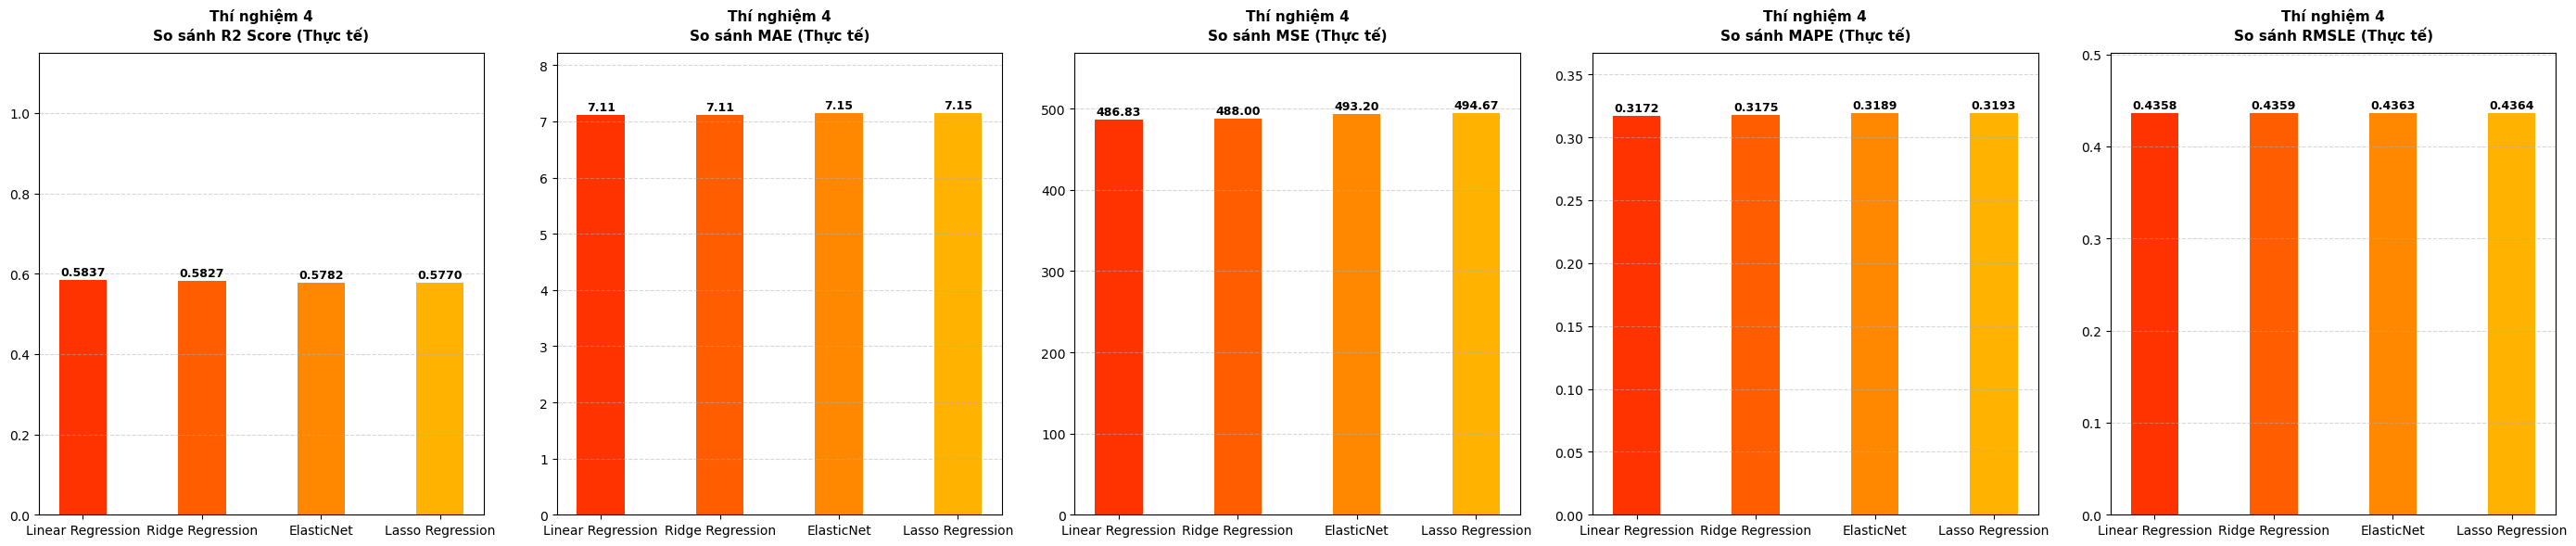

In [87]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 5.4: THÍ NGHIỆM 4 - NHÓM HỒI QUY TRÊN DỮ LIỆU LINEAR (TỰ ĐỘNG ĐIỀN MEDIAN)
# ───────────────────────────────────────────────────────────────────────
# CƠ CHẾ: Tự động điền khuyết -> Train LOG -> Đánh giá trên GIÁ TRỊ THỰC
# ═══════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
# ĐÃ SỬA: Import thêm hàm tính MAPE và MSLE (để tính RMSLE)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, mean_squared_log_error

print("🧪 Chạy Thí nghiệm 4: Toàn bộ nhóm Hồi quy trên Dữ liệu Linear (Train LOG - Đánh giá THỰC)...\n")

# 🛠️ BƯỚC SỬA LỖI: Kiểm tra và tự động điền khuyết bằng Median nếu xuất hiện NaN
nan_in_train = X_train_linear_final.isna().sum().sum()
nan_in_test = X_test_linear_final.isna().sum().sum()

if nan_in_train > 0 or nan_in_test > 0:
    print(f"⚠️ Phát hiện có {nan_in_train} ô trống ở tập Train và {nan_in_test} ô trống ở tập Test.")
    print("⏳ Đang tự động lấp đầy các ô trống bằng giá trị Trung vị (Median)...")
    
    # Khởi tạo bộ điền khuyết bằng chiến lược 'median'
    imputer = SimpleImputer(strategy='median')
    
    # Học trung vị từ tập Train và điền khuyết cho cả hai tập Train/Test
    X_train_linear_clean = pd.DataFrame(imputer.fit_transform(X_train_linear_final), columns=X_train_linear_final.columns)
    X_test_linear_clean = pd.DataFrame(imputer.transform(X_test_linear_final), columns=X_test_linear_final.columns)
    print("✅ Đã xử lý làm sạch dữ liệu xong!\n")
else:
    print("✨ Tuyệt vời! Dữ liệu đầu vào hoàn toàn sạch sẽ, không có NaN.\n")
    X_train_linear_clean = X_train_linear_final.copy()
    X_test_linear_clean = X_test_linear_final.copy()


# 1. KHỞI TẠO TẤT CẢ CÁC MÔ HÌNH THUỘC NHÓM HỒI QUY
linear_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001, max_iter=10000), 
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000)
}

results_4 = []

# 2. HUẤN LUYỆN VÀ ĐÁNH GIÁ (CHUYỂN ĐỔI NGƯỢC VỀ THANG ĐO THỰC TẾ)
for name, model in linear_models.items():
    try:
        # Kiểm tra tính đồng bộ kích thước dữ liệu trước khi huấn luyện
        if len(X_train_linear_clean) != len(y_train_linear):
            raise ValueError(f"Lệch kích thước! X_train có {len(X_train_linear_clean)} dòng, y_train có {len(y_train_linear)} dòng.")
            
        # Huấn luyện trên tập dữ liệu ĐÃ SẠCH NAN (X_train_linear_clean)
        model.fit(X_train_linear_clean, y_train_linear)
        preds_log = model.predict(X_test_linear_clean)
        
        # Chuyển đổi ngược giá trị dự đoán từ dạng Log về dạng Giá Gốc thực tế
        preds_real = np.expm1(preds_log)
        
        # Tính toán các chỉ số cơ bản
        r2 = r2_score(y_test_tree, preds_real)
        mae = mean_absolute_error(y_test_tree, preds_real)
        mse = mean_squared_error(y_test_tree, preds_real)
        
        # ĐÃ THÊM: Tính toán MAPE trên giá trị gốc thực tế
        mape = mean_absolute_percentage_error(y_test_tree, preds_real)
        
        # ĐÃ THÊM: Tính toán RMSLE trên giá trị gốc thực tế
        # (Sử dụng np.clip để đảm bảo an toàn tuyệt đối, tránh giá trị âm phá hỏng hàm log)
        preds_real_clipped = np.clip(preds_real, 0, None)
        rmsle = np.sqrt(mean_squared_log_error(y_test_tree, preds_real_clipped))
        
        results_4.append({
            "Mô hình": name, 
            "R2 Score": round(r2, 4), 
            "MAE": round(mae, 2), 
            "MSE": round(mse, 2), 
            "MAPE": round(mape, 4),      # Bổ sung vào bảng kết quả
            "RMSLE": round(rmsle, 4),    # Bổ sung vào bảng kết quả
            "Status": "Success"
        })
        print(f"🚀 {name:<18} -> Huấn luyện thành công!")
    except Exception as e:
        results_4.append({
            "Mô hình": name, "R2 Score": 0, "MAE": 0, "MSE": 0, 
            "MAPE": 0, "RMSLE": 0, "Status": f"Failed ({type(e).__name__})"
        })
        print(f"❌ {name:<18} -> Thất bại! (Lỗi: {e})")

# 3. TỔNG HỢP VÀ VẼ BIỂU ĐỒ
df_res4 = pd.DataFrame(results_4)
display(df_res4)

# Lọc các mô hình thành công để sắp xếp và vẽ biểu đồ
success_res4 = df_res4[df_res4["Status"] == "Success"].sort_values(by="R2 Score", ascending=False)

if not success_res4.empty:
    # ĐÃ SỬA: Tăng số lượng biểu đồ (subplots) từ 3 lên 5 để chứa thêm MAPE và RMSLE
    fig, axes = plt.subplots(1, 5, figsize=(28, 6))
    
    # ĐÃ SỬA: Bổ sung 'MAPE' và 'RMSLE' vào danh sách duyệt vẽ
    metrics = ['R2 Score', 'MAE', 'MSE', 'MAPE', 'RMSLE']
    colors = plt.cm.autumn(np.linspace(0.2, 0.7, len(success_res4)))

    for i, metric in enumerate(metrics):
        ax = axes[i]
        bars = ax.bar(success_res4['Mô hình'], success_res4[metric], color=colors, width=0.4)
        ax.set_title(f'Thí nghiệm 4\nSo sánh {metric} (Thực tế)', fontsize=11, fontweight='bold', pad=10)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        if metric == 'R2 Score': 
            ax.set_ylim(0, 1.15)
        else: 
            ax.set_ylim(0, success_res4[metric].max() * 1.15)
            
        for bar in bars:
            h = bar.get_height()
            # Định dạng hiển thị văn bản: 4 chữ số thập phân cho R2, MAPE, RMSLE; các metric khác in 2 chữ số
            text_format = f"{h:,.4f}" if metric in ['R2 Score', 'MAPE', 'RMSLE'] else f"{h:,.2f}"
            ax.text(bar.get_x() + bar.get_width()/2., h + (ax.get_ylim()[1]*0.01), 
                    text_format, ha='center', fontweight='bold', fontsize=9)
            
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Không có mô hình nào huấn luyện thành công để vẽ biểu đồ.")

📊 Đang vẽ biểu đồ chẩn đoán cho mô hình XGBoost...


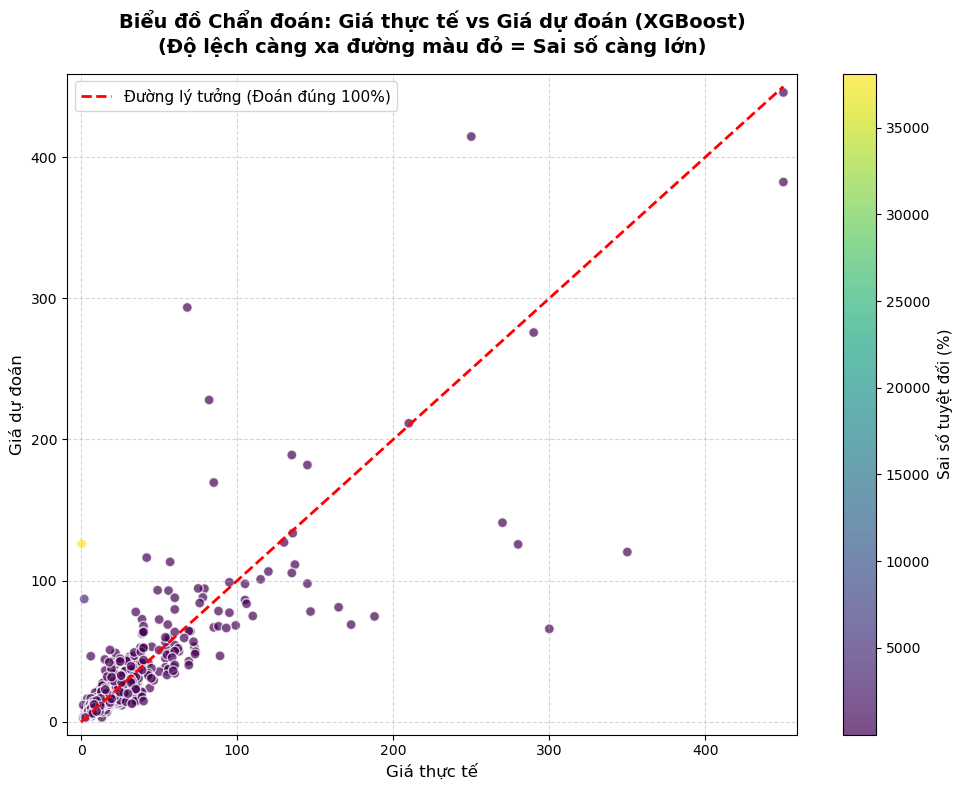

In [88]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 6: BIỂU ĐỒ CHẨN ĐOÁN MÔ HÌNH (XGBOOST SCATTER PLOT) - ĐÃ SỬA LỖI SIZE VÀ INF
# ═══════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

print("📊 Đang vẽ biểu đồ chẩn đoán cho mô hình XGBoost...")

# 0. Đồng bộ tên biến nhãn thực tế từ Cell 1 (Đảm bảo 100% khớp số dòng)
y_train_real = y_train_tree
y_test_real = y_test_tree 

# 1. Huấn luyện và dự đoán bằng XGBoost (Sử dụng dữ liệu Tree gốc)
best_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)

# SỬA LỖI KÍCH THƯỚC VÀ LOGIC: Fit bằng y_train_real (Không dùng y_train_log)
if len(X_train_tree_final) != len(y_train_real):
    raise ValueError(f"Lệch kích thước! X_train có {len(X_train_tree_final)} dòng, y_train có {len(y_train_real)} dòng.")
    
best_model.fit(X_train_tree_final, y_train_real)
y_pred_real_xgb = best_model.predict(X_test_tree_final)

# 2. Tính toán sai số phần trăm tuyệt đối (MAPE %)
# Thêm epsilon nhỏ (1e-8) vào mẫu số để phòng tránh lỗi Division by Zero (chia cho 0) sinh ra INF
epsilon = 1e-8
absolute_percentage_errors = np.abs((y_test_real - y_pred_real_xgb) / (y_test_real + epsilon)) * 100

# 3. Vẽ đồ thị Scatter Plot
plt.figure(figsize=(10, 8))

# Đường chuẩn y = x
max_val = max(np.max(y_test_real), np.max(y_pred_real_xgb))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Đường lý tưởng (Đoán đúng 100%)')

# Điểm phân bố (màu thể hiện sai số)
scatter = plt.scatter(y_test_real, y_pred_real_xgb, 
                      c=absolute_percentage_errors, 
                      cmap='viridis', alpha=0.7, edgecolors='w', s=50)

cbar = plt.colorbar(scatter)
cbar.set_label('Sai số tuyệt đối (%)', fontsize=11)

plt.title('Biểu đồ Chẩn đoán: Giá thực tế vs Giá dự đoán (XGBoost)\n(Độ lệch càng xa đường màu đỏ = Sai số càng lớn)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Giá thực tế', fontsize=12)
plt.ylabel('Giá dự đoán', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# Tránh đồ thị bị ép quá sát viền
plt.xlim(-max_val*0.02, max_val*1.02)
plt.ylim(-max_val*0.02, max_val*1.02)

plt.tight_layout()
plt.show()